# 可选实验：代价函数
<figure>
    <center> <img src="../work/images/C1_W1_L3_S2_Lecture_b.png"  style="width:1000px;height:200px;" ></center>
</figure>


## 目标
在本实验中，你将：
- 实现并探索用于单变量线性回归的 `cost` 函数。

## 工具
在本实验中，我们将使用：
- NumPy：常用的科学计算库；
- Matplotlib：常用的数据绘图库；
- 本地目录中 lab_utils_uni.py 文件里的绘图例程。

In [6]:
! pip install ipympl
%pip install -U ipywidgets

Looking in indexes: https://mirrors.aliyun.com/pypi/simple/



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://mirrors.aliyun.com/pypi/simple/
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
from lab_utils_uni import plt_intuition, plt_stationary, plt_update_onclick, soup_bowl
plt.style.use('./deeplearning.mplstyle')

In [8]:
import jupyterlab
print(jupyterlab.__version__)

4.6.3


In [9]:
import ipywidgets
print(ipywidgets.__version__)

8.1.9


## 问题陈述

你希望构建一个能够根据房屋面积预测房价的模型。
让我们使用与上一个实验相同的两个数据点——一套 1000 平方英尺的房屋售价为 \\$300,000，另一套 2000 平方英尺的房屋售价为 \\$500,000。


| 面积（1000 平方英尺）     | 价格（千美元） |
| -------------------| ------------------------ |
| 1                 | 300                      |
| 2                  | 500                      |

In [10]:
import ipywidgets as widgets

widgets.IntSlider(
    value=150,
    min=0,
    max=400,
    step=10,
    description='w'
)

IntSlider(value=150, description='w', max=400, step=10)

In [11]:
x_train = np.array([1.0, 2.0])           #(size in 1000 square feet)
y_train = np.array([300.0, 500.0])           #(price in 1000s of dollars)

## 计算代价
本作业中的“代价”一词可能有些容易混淆，因为数据本身是房屋成本数据。这里的代价用于衡量模型预测房屋目标价格的好坏程度；房屋数据中的数值则使用“价格”一词。

单变量代价公式为：
  $$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2 \tag{1}$$ 
 
其中：
  $$f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{2}$$
  
- $f_{w,b}(x^{(i)})$ 是使用参数 $w,b$ 对样本 $i$ 作出的预测。  
- $(f_{w,b}(x^{(i)}) -y^{(i)})^2$ 是目标值与预测值之差的平方。  
- 对全部 $m$ 个样本的这些差值求和，再除以 `2m`，得到代价 $J(w,b)$。  
>注意：课程中的求和范围通常从 1 到 m，而代码中的范围将从 0 到 m-1。

下面的代码通过遍历每个样本来计算代价。在每次循环中：
- 计算一个预测值 `f_wb`
- 计算目标值与预测值之差并取平方。
- 将其累加到总代价中。

In [12]:
def compute_cost(x, y, w, b): 
    """
    Computes the cost function for linear regression.
    
    Args:
      x (ndarray (m,)): Data, m examples 
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters  
    
    Returns
        total_cost (float): The cost of using w,b as the parameters for linear regression
               to fit the data points in x and y
    """
    # number of training examples
    m = x.shape[0] 
    
    cost_sum = 0 
    for i in range(m): 
        f_wb = w * x[i] + b   
        cost = (f_wb - y[i]) ** 2  
        cost_sum = cost_sum + cost  
    total_cost = (1 / (2 * m)) * cost_sum  

    return total_cost

## 代价函数直观理解

<img align="left" src="../work/images/C1_W1_Lab02_GoalOfRegression.PNG"    style=" width:380px; padding: 10px;  " /> 您的目标是找到一个参数为 $w,b$ 的模型 $f_{w,b}(x) = wx + b$，它能根据输入 $x$ 准确预测房屋价值。代价用于衡量模型在训练数据上的准确程度。

上面的代价公式 (1) 表明，如果能够选择 $w$ 和 $b$，使预测值 $f_{w,b}(x)$ 与目标数据 $y$ 一致，那么 $(f_{w,b}(x^{(i)}) - y^{(i)})^2 $ 项将为零，代价也会最小化。在这个简单的两点示例中，您可以做到这一点！

在上一个实验中，您已确定 $b=100$ 给出了最优解，因此我们将 $b$ 设为 100，并重点研究 $w$。

<br/>
请在下方使用滑块控件选择使代价最小的 $w$ 值。图表可能需要几秒钟才能更新。

In [13]:
plt_intuition(x_train,y_train)

interactive(children=(IntSlider(value=150, description='w', max=400, step=10), Output()), _dom_classes=('widge…

图中有几点值得一提：
- 当 $w = 200$ 时，代价最小，这与此前实验的结果一致
- 由于代价方程中目标值与预测值之差会被平方，因此当 $w$ 过大或过小时，代价都会迅速增大。
- 使用通过最小化代价选出的 `w` 和 `b`，得到的直线能够完美拟合数据。

## 代价函数可视化——三维图

通过三维图或等高线图，可以看到代价如何同时随 `w` 和 `b` 变化。  
值得注意的是，本课程中的某些绘图可能相当复杂。课程已提供绘图例程；阅读代码有助于熟悉相关方法，但并不是顺利完成课程所必需的。这些例程位于本地目录的 lab_utils_uni.py 中。

### 更大的数据集
查看包含更多数据点的情形很有启发性。该数据集包含不在同一直线上的数据点。这对代价公式意味着什么？我们能否找到使代价为 0 的 $w$ 和 $b$？

In [14]:
x_train = np.array([1.0, 1.7, 2.0, 2.5, 3.0, 3.2])
y_train = np.array([250, 300, 480,  430,   630, 730,])

在等高线图中单击一个点，选择 `w` 和 `b`，以获得最低代价。请使用等高线引导选择。注意，图表可能需要几秒钟才能更新。

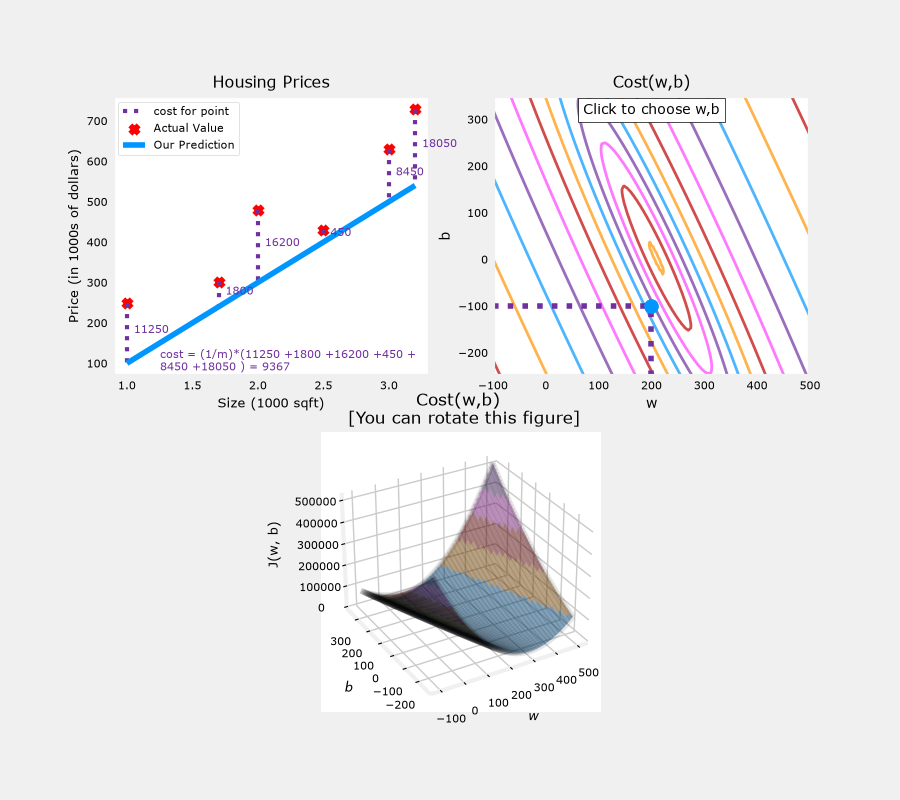

In [15]:
plt.close('all') 
fig, ax, dyn_items = plt_stationary(x_train, y_train)
updater = plt_update_onclick(fig, ax, x_train, y_train, dyn_items)

请注意上面左图中的虚线。它们表示训练集中每个样本对代价的贡献部分。在本例中，大约为 $w=209$ 和 $b=2.4$ 的值可得到较低代价。请注意，由于训练样本不在一条直线上，因此最小代价不为零。

### 凸代价曲面
代价函数对损失取平方这一事实确保了“误差曲面”像汤碗一样是凸的。沿所有维度的梯度方向移动，总能到达一个最小值。在前一幅图中，由于 $w$ 和 $b$ 两个维度的尺度不同，这一点不容易看出来。课程中展示了下面这幅 $w$ 与 $b$ 对称的图：

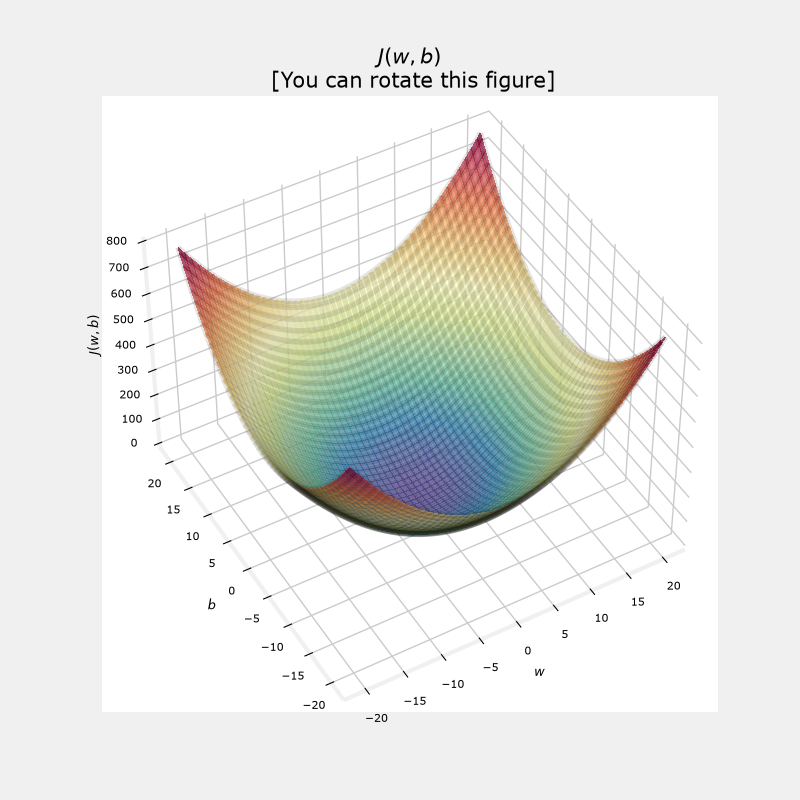

In [16]:
soup_bowl()

# 恭喜！
你已经学会以下内容：
 - 代价方程可以衡量预测与训练数据的匹配程度。
 - 最小化代价可以得到 $w$、$b$ 的最优值。